In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
from DecisionTree import DecisionTree

In [16]:
data = datasets.load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTree(max_depth=4)
tree.fit(X_train, y_train)
predictions = tree.predict(X_test)

def accuracy(y_test, y_pred):
    return np.sum(y_test == y_pred) / len(y_test)

acc = accuracy(y_test, predictions)
print(f"Accuracy: {acc * 100:.2f}%")

Accuracy: 94.74%


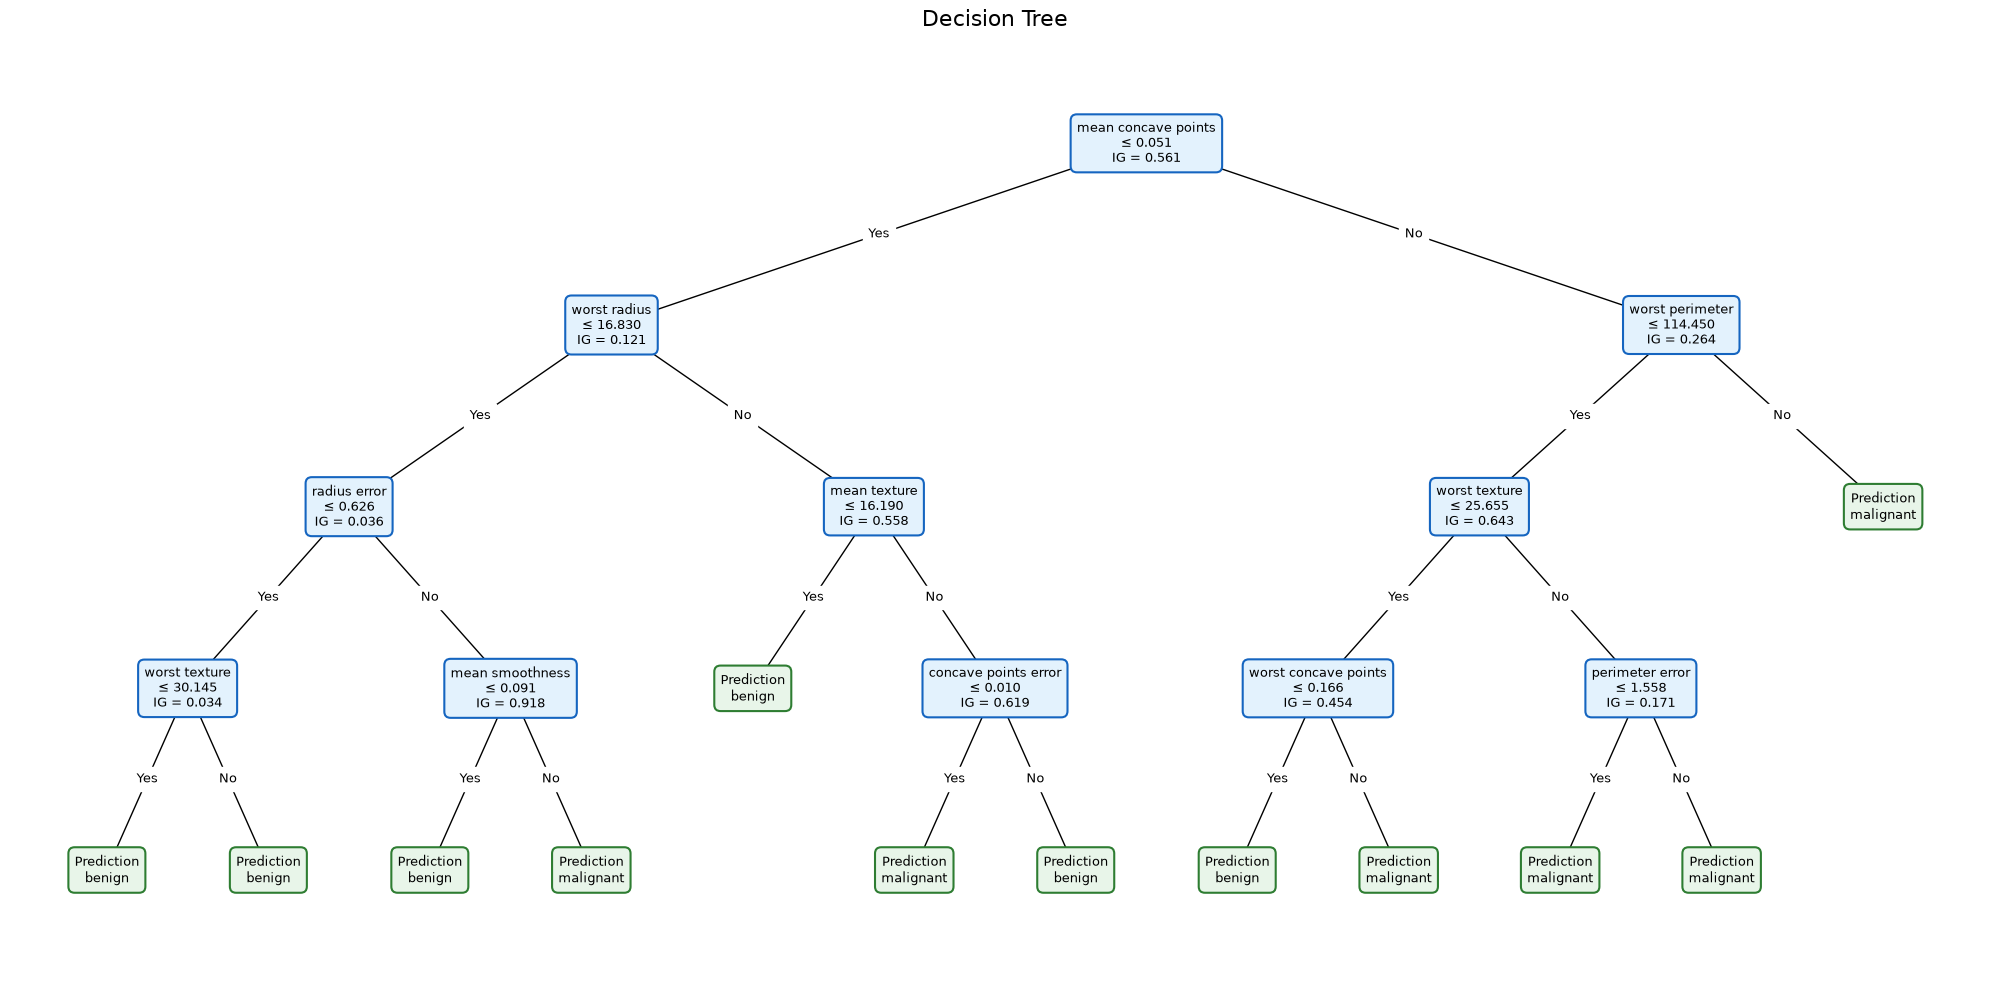

In [17]:
def plot_decision_tree(tree, feature_names=None, class_names=None, figsize=(18, 9)):
    positions = {}
    next_leaf = [0]
    max_depth = [0]

    def set_positions(node, depth=0):
        max_depth[0] = max(max_depth[0], depth)

        if node.is_leaf_node():
            x = next_leaf[0]
            next_leaf[0] += 1
        else:
            left_x = set_positions(node.left, depth + 1)
            right_x = set_positions(node.right, depth + 1)
            x = (left_x + right_x) / 2

        positions[node] = (x, -depth)
        return x

    set_positions(tree.root)

    fig, ax = plt.subplots(figsize=figsize)

    def draw(node):
        x, y = positions[node]

        if node.is_leaf_node():
            class_value = int(node.value)

            if class_names is not None:
                class_label = class_names[class_value]
            else:
                class_label = class_value

            label = f"Prediction\n{class_label}"
            facecolor = "#E8F5E9"
            edgecolor = "#2E7D32"

        else:
            if feature_names is not None:
                feature_name = feature_names[node.feature_index]
            else:
                feature_name = f"Feature {node.feature_index}"

            label = (
                f"{feature_name}\n"
                f"≤ {node.threshold:.3f}\n"
                f"IG = {node.information_gain:.3f}"
            )

            facecolor = "#E3F2FD"
            edgecolor = "#1565C0"

            children = [
                (node.left, "Yes"),
                (node.right, "No")
            ]

            for child, branch_label in children:
                child_x, child_y = positions[child]

                ax.plot(
                    [x, child_x],
                    [y, child_y],
                    color="black",
                    linewidth=1
                )

                ax.text(
                    (x + child_x) / 2,
                    (y + child_y) / 2,
                    branch_label,
                    fontsize=9,
                    ha="center",
                    va="center",
                    backgroundcolor="white"
                )

                draw(child)

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=9,
            bbox={
                "boxstyle": "round,pad=0.5",
                "facecolor": facecolor,
                "edgecolor": edgecolor,
                "linewidth": 1.5
            },
            zorder=3
        )

    draw(tree.root)

    number_of_leaves = max(next_leaf[0], 1)

    ax.set_xlim(
        -0.6,
        max(number_of_leaves - 0.4, 0.6)
    )

    ax.set_ylim(
        -max_depth[0] - 0.6,
        0.6
    )

    ax.set_title("Decision Tree", fontsize=16)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_decision_tree(
    tree,
    feature_names=data.feature_names,
    class_names=data.target_names,
    figsize=(20, 10)
)